In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from build_dataset import build_dataset
from itertools import product
%load_ext autoreload
%autoreload 2
%matplotlib inline

#### Taking the words of the corpus

In [2]:
words_corpus = open("names.txt", "r").read().splitlines()
words_corpus[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
print(f"The total len of the words of the corpus are {len(words_corpus)}")

The total len of the words of the corpus are 32033


#### Build the vocabulary of characters and mapping to/from integers

In [4]:
chars_corpus = sorted(list(set(''.join(words_corpus)))) #Set so it doesnt repeat the words
print(f"This are the words in the corpus{chars_corpus} and the len {len(chars_corpus)}")

This are the words in the corpus['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] and the len 26


In [5]:
stoi = {letter:index+1 for index, letter in enumerate(chars_corpus)} #This for making the letters and the index
stoi['.'] = 0 #Its the first index its going to be .
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [6]:
itos = {index:letter for letter,index in stoi.items()}
print(len(itos))

27


#### Build the Dataset

In [26]:
import random
block_size_context = 3  #the context length: how many characters 
                        # the model sees to predict the next one
                        # e.g. "_ _ _ -> ?"


random.seed(42) #This is for reproducibility
random.shuffle(words_corpus)
n1 = int(0.80 * len(words_corpus)) #This is for the training set
n2 = int(0.90 * len(words_corpus)) #This is for the validation set and the test set

X_training, Y_training = build_dataset(words_corpus=words_corpus[:n1],block_size=block_size_context, stoi=stoi) #until 80%
X_validation, Y_validation = build_dataset(words_corpus=words_corpus[n1:n2], block_size=block_size_context, stoi=stoi) #10 for validation
X_test, Y_test = build_dataset(words_corpus=words_corpus[n2:], block_size=block_size_context, stoi=stoi)#10 for test

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [27]:
import torch.nn.init as init

#MLP revisited hyper parameters
embedding_dim = 10 #The dimensionality of the character embedding
hidden_size_first_layer = block_size_context * embedding_dim #This is because we have the number of neurons is the embedding dim * number of layers
hidden_size_second_layer = 200 # the number of neurons in the hidden layer of the MLP
batch_size = 32
lenght_characters_dataset = len(itos)
generator = torch.Generator().manual_seed(2147483647)


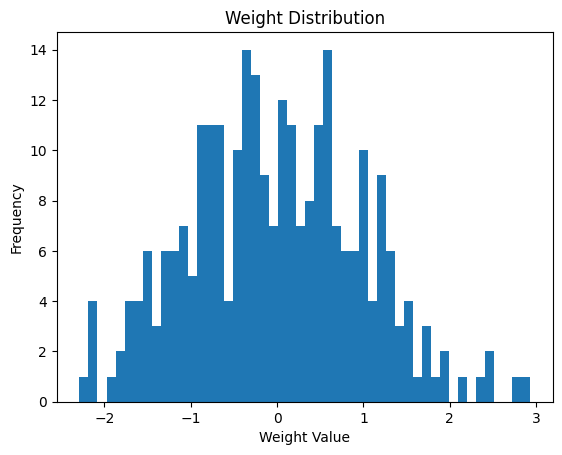

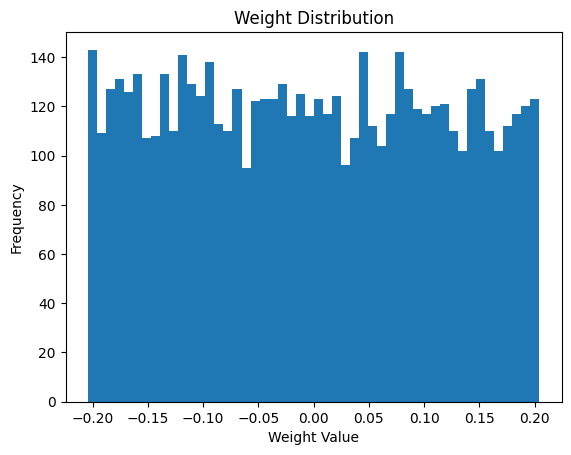

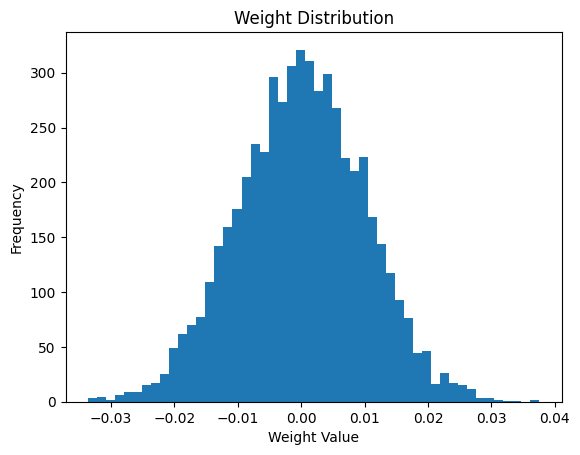

In [28]:

C = torch.randn((lenght_characters_dataset, embedding_dim), generator=generator) #The look out matrix, is the matrix with the embeddings
W1 = torch.randn((hidden_size_first_layer, hidden_size_second_layer), generator=generator) # 30 neurons first layers, 200 neurons second layer
#b1 = torch.zeros((hidden_size_second_layer)) # The bias is always the next layer
W2 = torch.randn((hidden_size_second_layer, lenght_characters_dataset)) #The 200 neurons of second layer, the number of outputs
b2 = torch.randn(lenght_characters_dataset, generator=generator) * 0

W2 = W2 * 0.01
init.kaiming_uniform_(W1, a=5/3, nonlinearity="tanh")


#BatchNorm parameters
bngain = torch.ones((1, hidden_size_second_layer))
bnbias = torch.zeros((1, hidden_size_second_layer))
bnmean_running = torch.zeros((1, hidden_size_second_layer))
bnstd_running = torch.ones((1, hidden_size_second_layer))



parameters = [C, W1, W2, b2, bngain, bnbias]


C_weights = C.detach().numpy()
plt.hist(C_weights.flatten(), bins=50)
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()


W1_weights = W1.detach().numpy()
plt.hist(W1_weights.flatten(), bins=50)
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()


W2_weights = W2.detach().numpy()
plt.hist(W2_weights.flatten(), bins=50)
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()

In [29]:
print(f"The total number of parameters {sum(p.nelement() for p in parameters)}")

The total number of parameters 12097


In [30]:
for p in parameters:
    p.requires_grad = True #Functions so the gradients are active to being changed and when loss.backward() there is going to be and update

In [31]:
lre = torch.linspace(-3, 0 , 1000) #To create from range -3 to 0 samples
lrs = 10**lre #To normalize it so we have the learning lare brom 0.0010 to 1

In [32]:
lr_index = []
loss_index = []
step_index = []
EPOCHS = 200000
max_steps = 200000

In [33]:
idx = 98869
contexto = X_training[idx]
print(contexto)  
siguiente = Y_training[idx]
print(siguiente)
print([itos[i.item()] for i in contexto], '->', itos[siguiente.item()])

tensor([ 0, 13,  1])
tensor(3)
['.', 'm', 'a'] -> c


In [39]:
#First layer -> BatchNorm -> Second Layer(tahn)

loss_total = list()
for index in range(EPOCHS):
    #Creating the minibatch
    ix = torch.randint(0, X_training.shape[0], (batch_size,), generator=generator) #Cada iteración → 32 índices random de TODO el dataset → El mismo ejemplo puede aparecer en muchas iteraciones, o no aparecer nunca en miles de pasos
    Xb, Yb = X_training[ix], Y_training[ix]
    
    #Forward Pass
    embedding = C[Xb]
    embcat = embedding.view(embedding.shape[0], -1)
    
    
    #linear Layer
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    
    
    #BatchNorm 
    # -------------------------------------------------------------
    bnmeani = hpreact.mean(0,keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        
    # -------------------------------------------------------------
    #Non-Linearity
    hidden_layer_tahn = torch.tanh(hpreact)  #View -> (32, 3, 10) → (32, 30)
    logits = hidden_layer_tahn @ W2 + b2 #(32, 27) its the one to see how weel it does the prediction
    loss = F.cross_entropy(logits, Yb)
    
    #BackWard pass
    for p in parameters:
        p.grad = None #Transform the gradients to 0 so it can be update
    loss.backward()

    # update
    lr = 0.1 if index < 100000 else 0.01
    for p in parameters:
        if p.grad is not None:
            p.data += -lr * p.grad

    #track stats
    if index % 10000 == 0:
        print(f'{index:7d}/{max_steps:7d}: {loss.item():.4f}')
    #lr_index.append(lre[index])
    #step_index.append(index)
    loss_index.append(loss.log10().item())
    #loss_total.append(loss.item())

print(loss.item())

      0/ 200000: 2.0704
  10000/ 200000: 2.2257
  20000/ 200000: 2.2647
  30000/ 200000: 2.2771
  40000/ 200000: 2.0259
  50000/ 200000: 2.5403
  60000/ 200000: 2.0494
  70000/ 200000: 2.1405
  80000/ 200000: 1.9832
  90000/ 200000: 2.0163
 100000/ 200000: 2.7324
 110000/ 200000: 2.2665
 120000/ 200000: 1.8227
 130000/ 200000: 2.1839
 140000/ 200000: 1.8658
 150000/ 200000: 2.1601
 160000/ 200000: 2.0339
 170000/ 200000: 1.9170
 180000/ 200000: 2.2266
 190000/ 200000: 2.1298
1.8171652555465698


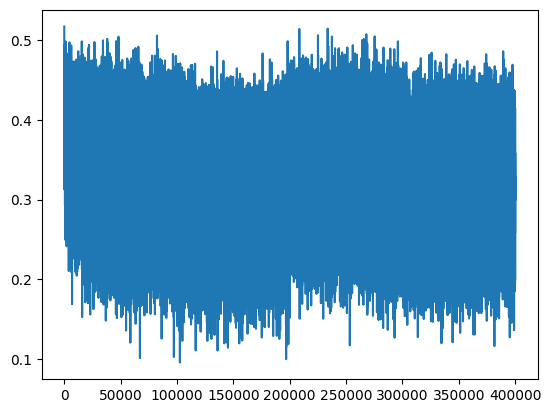

In [40]:
plt.plot(loss_index)

### With BatchNorm


In [41]:
# Calibrate the batch norm at the end of the training == Inference
with torch.no_grad():
    # pass the training set through
    emb = C[X_training]
    print(emb.shape)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1
    # Measure the mean/std over the entire training set
    bmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

torch.Size([182580, 3, 10])


In [42]:
@torch.no_grad() #This decorator disables gradient tracking
def split_loss(split : str) -> None:
    x, y = {
        'train' : (X_training, Y_training),
        'val' : (X_validation, Y_validation),
        'test' : (X_test, Y_test)
    }[split] # Its like a if statement of the code
    
    emb = C[x] #(N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    hidden_layer_tahn = torch.tanh(hpreact)
    logits = hidden_layer_tahn @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.057955265045166
val 2.104189395904541
